# Start fare regression
Import libraries and load the dataset

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

df = pd.read_csv("titanic.csv")

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


# Define the target and features

Our target is fare. We must exclude it from the input features to prevent target leakage.

In [2]:

regression_features = [
    "pclass",
    "sex",
    "age",
    "sibsp",
    "parch",
    "embarked"
]

X_reg = df[regression_features]
y_reg = df["fare"]

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg,
    y_reg,
    test_size=0.20,
    random_state=42
)

print("Training rows:", len(X_reg_train))
print("Test rows:", len(X_reg_test))
print("Missing values in training features:")
print(X_reg_train.isna().sum())

Training rows: 712
Test rows: 179
Missing values in training features:
pclass        0
sex           0
age         140
sibsp         0
parch         0
embarked      2
dtype: int64


# Build the regression pipeline

In [4]:

reg_numeric_features = [
    "pclass",
    "age",
    "sibsp",
    "parch"
]

reg_categorical_features = [
    "sex",
    "embarked"
]

reg_numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

reg_categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

reg_preprocessor = ColumnTransformer([
    ("numeric", reg_numeric_pipeline, reg_numeric_features),
    ("categorical", reg_categorical_pipeline, reg_categorical_features)
])

fare_model = Pipeline([
    ("preprocessor", reg_preprocessor),
    ("regressor", LinearRegression())
])

fare_model.fit(X_reg_train, y_reg_train)

print("Linear regression model trained successfully.")

Linear regression model trained successfully.


# Missing-value treatment

The training dataset contained 140 missing age values and two missing embarkation values. Missing ages were imputed using the median, while missing embarkation ports were imputed using the most frequent category. Both transformations were fitted within the training pipeline to prevent test-data leakage. Median imputation provides a simple baseline, although the substantial proportion of missing ages may reduce the information available to the regression model.

# Evaluate the model

In [5]:

fare_predictions = fare_model.predict(X_reg_test)

mae = mean_absolute_error(y_reg_test, fare_predictions)
rmse = np.sqrt(mean_squared_error(y_reg_test, fare_predictions))
r2 = r2_score(y_reg_test, fare_predictions)

n = len(y_reg_test)
p = len(
    fare_model.named_steps["preprocessor"].get_feature_names_out()
)

adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print(f"MAE:         {mae:.4f}")
print(f"RMSE:        {rmse:.4f}")
print(f"R²:          {r2:.4f}")
print(f"Adjusted R²: {adjusted_r2:.4f}")
print(f"Test rows:   {n}")
print(f"Features after encoding: {p}")

MAE:         20.8094
RMSE:        30.4731
R²:          0.3999
Adjusted R²: 0.3679
Test rows:   179
Features after encoding: 9


# Observation:
The multiple linear regression model achieved an MAE of £20.81, an RMSE of £30.47, an R² of 0.3999 and an adjusted R² of 0.3679 on 179 test observations. The R² indicates that the selected passenger characteristics explain approximately 40% of the observed variation in fares, while approximately 60% remains unexplained. The lower adjusted R² accounts for the nine encoded predictors. The RMSE exceeds the MAE, indicating that larger prediction errors have a substantial effect on overall performance. Additional fare-related factors and nonlinear relationships may help explain the remaining variation.

# Create the residual plots

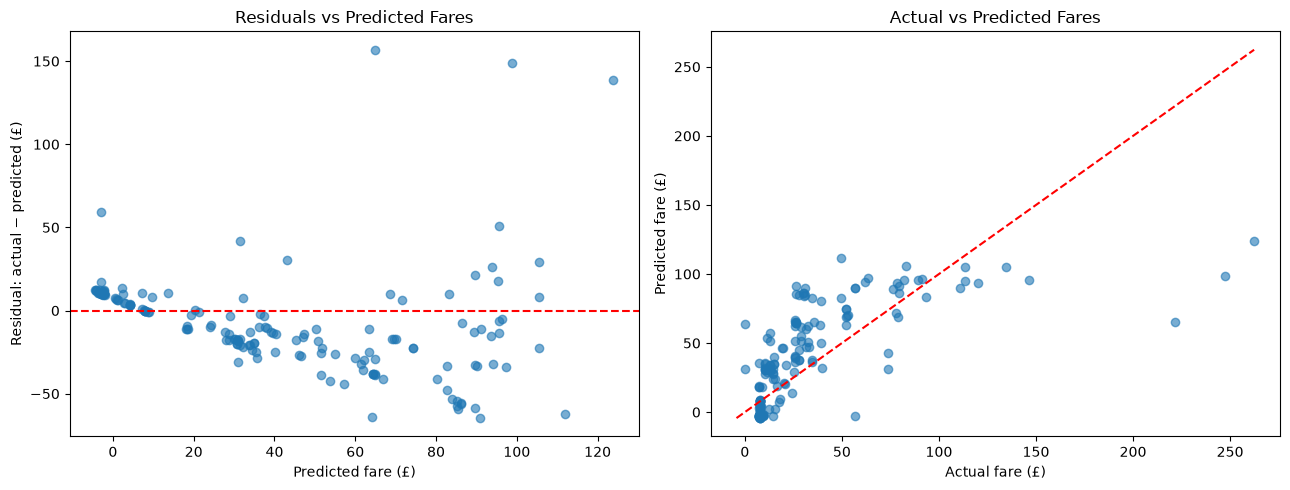

In [6]:

residuals = y_reg_test - fare_predictions

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Residuals versus predicted fares
axes[0].scatter(
    fare_predictions,
    residuals,
    alpha=0.6
)
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_xlabel("Predicted fare (£)")
axes[0].set_ylabel("Residual: actual − predicted (£)")
axes[0].set_title("Residuals vs Predicted Fares")

# Actual versus predicted fares
axes[1].scatter(
    y_reg_test,
    fare_predictions,
    alpha=0.6
)
min_fare = min(y_reg_test.min(), fare_predictions.min())
max_fare = max(y_reg_test.max(), fare_predictions.max())
axes[1].plot(
    [min_fare, max_fare],
    [min_fare, max_fare],
    color="red",
    linestyle="--"
)
axes[1].set_xlabel("Actual fare (£)")
axes[1].set_ylabel("Predicted fare (£)")
axes[1].set_title("Actual vs Predicted Fares")

plt.tight_layout()
plt.show()

# Residual analysis

The residual plot reveals a non-random pattern, with many negative residuals at moderate to high predicted fares and several large positive residuals. This suggests that the linear regression model does not fully capture the relationship between the selected passenger characteristics and fare. The varying spread of residuals also suggests possible heteroscedasticity.

The actual-versus-predicted plot shows that predictions are compressed relative to actual fares. In particular, the model substantially underpredicts some of the most expensive tickets. These findings are consistent with the model's R² of 0.3999 and indicate that the selected features and a linear relationship explain only part of the variation in passenger fares.